In [98]:
# ! pip install numpy pandas matplotlib scikit-learn
! pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [100]:
df = pd.read_csv("data.csv")


### ۱. اطلاعات کلی در مورد داده ها ارائه کنید. 


In [101]:
df.head()

,Country,Population,Militarydeaths from all causes,Civilian deaths due tomilitary activity and crimes against humanity,Civilian deaths due towar-related famine and disease,Totaldeaths,Deaths on population,Average Deaths as % of1939 population,Militarywounded
0,Albania,1073000.0,"30,000[17]",NaN,NaN,"30,000",0.027958993,2.8,NaN
1,Australia,6968000.0,"39,700[18]",700[19],NaN,"40,400",0.005797933,0.58,"39,803[20]"
2,Austria,6653000.0,Included with Germany,Included with Germany,NaN,0,0,(See table below.)S2,Included with Germany
3,Belgium,8387000.0,"12,000[21]","76,000[21]",NaN,"88,000",0.010492429,1.05,"55,513[20]"
4,Brazil,40289000.0,"1,000[20]","1,000",NaN,"2,000",4.96E-05,0,"4,222[20]"


In [102]:
df.describe()

,Population
count,5.900000e+01
mean,3.367933e+07
std,8.558759e+07
min,3.400000e+03
25%,2.772500e+06
50%,8.387000e+06
75%,1.851000e+07
max,5.175680e+08


In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Country                                                              59 non-null     str    
 1   Population                                                           59 non-null     float64
 2   Militarydeaths from all causes                                       45 non-null     str    
 3   Civilian deaths due tomilitary activity and crimes against humanity  48 non-null     str    
 4   Civilian deaths due towar-related famine and disease                 9 non-null      str    
 5   Totaldeaths                                                          57 non-null     str    
 6   Deaths on population                                                 57 non-null     str    
 7   Average Deaths as % of

In [104]:
df.columns

Index(['Country', 'Population', 'Militarydeaths from all causes',
       'Civilian deaths due tomilitary activity and crimes against humanity',
       'Civilian deaths due towar-related famine and disease', 'Totaldeaths',
       'Deaths on population', 'Average Deaths as % of1939 population',
       'Militarywounded'],
      dtype='str')

In [105]:
df.nunique()

Country                                                                59
Population                                                             59
Militarydeaths from all causes                                         45
Civilian deaths due tomilitary activity and crimes against humanity    47
Civilian deaths due towar-related famine and disease                    9
Totaldeaths                                                            51
Deaths on population                                                   57
Average Deaths as % of1939 population                                  49
Militarywounded                                                        29
dtype: int64

In [106]:
df.size

540

In [107]:
df.nunique().sum()

np.int64(405)

In [108]:
df.shape

(60, 9)

In [109]:
df.duplicated().sum()

np.int64(0)

In [110]:
short_names = {
    'Population': 'Pop',
    'Military deaths from all causes': 'MilDeaths',
    'Civilian deaths due tomilitary activity and crimes against humanity': 'CivViolence',
    'Civilian deaths due towar-related famine and disease': 'CivFamineDisease',
    'Totaldeaths': 'TotalDeaths',
    'Deaths on population': 'DeathRate',
    'Average Deaths as % of1939 population': 'DeathPct1939',
    'Militarywounded': 'MilWounded'
}

df.rename(columns=short_names, inplace=True)


In [111]:
df.tail()

,Country,Pop,Militarydeaths from all causes,CivViolence,CivFamineDisease,TotalDeaths,DeathRate,DeathPct1939,MilWounded
55,Turkey,17370000.0,200[135],NaN,NaN,200,1.15E-05,0,NaN
56,United Kingdom,47760000.0,"383,700[137]","67,200[138][139]",NaN,"450,900",0.009440955,0.94,"376,239[20]"
57,United States,131028000.0,"407,300BF1","12,100BF2",NaN,"419,400",0.003200843,0.32,"671,801[20]"
58,Yugoslavia,15490000.0,"300,000[141] to 446,000[142]","581,000[142] to 1,400,000[141]",NaN,"1,027,000[142] to 1,700,000[141]",6.63 to 10.97,8.8,"425,000[20]"
59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### ۲. تعداد داد های از دست رفته را نشان کنید. 


In [112]:
miss_count = df.isnull().sum()
miss_count

Country                            1
Pop                                1
Militarydeaths from all causes    15
CivViolence                       12
CivFamineDisease                  51
TotalDeaths                        3
DeathRate                          3
DeathPct1939                       3
MilWounded                        31
dtype: int64

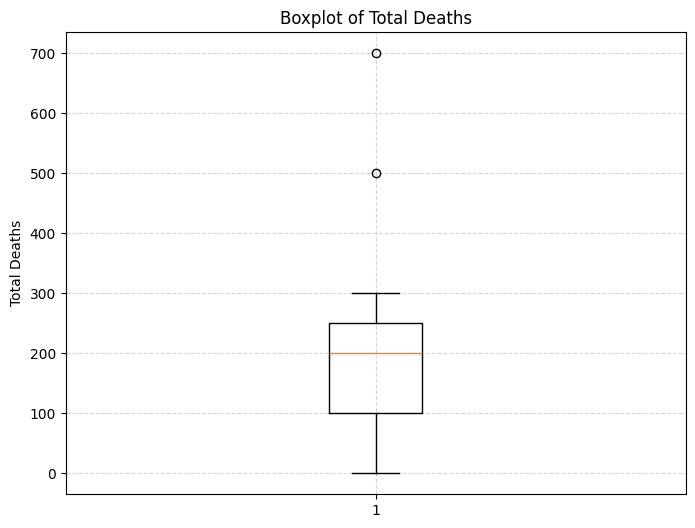

In [113]:


def to_numeric_safe(series):
    return pd.to_numeric(series, errors='coerce')

df['Pop'] = to_numeric_safe(df['Pop'])
df['TotalDeaths'] = to_numeric_safe(df['TotalDeaths'])

plt.figure(figsize=(8, 6))
plt.boxplot(df['TotalDeaths'].dropna())
plt.ylabel('Total Deaths')
plt.title('Boxplot of Total Deaths')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

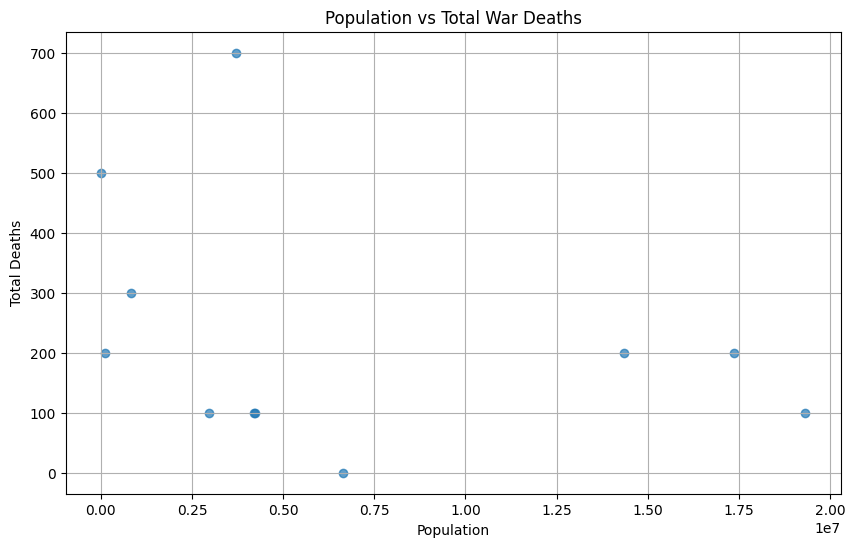

In [114]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Pop'], df['TotalDeaths'], alpha=0.7)
plt.xlabel('Population')
plt.ylabel('Total Deaths')
plt.title('Population vs Total War Deaths')
plt.grid(True)
plt.show()

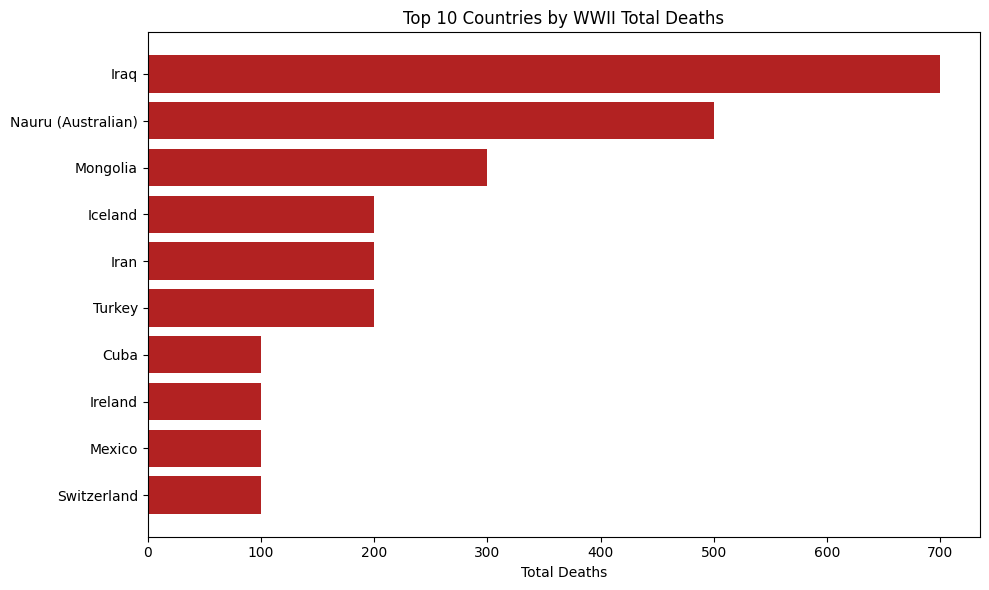

In [115]:
top10 = df.nlargest(10, 'TotalDeaths')
plt.figure(figsize=(10, 6))
plt.barh(top10['Country'], top10['TotalDeaths'], color='firebrick')
plt.xlabel('Total Deaths')
plt.title('Top 10 Countries by WWII Total Deaths')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

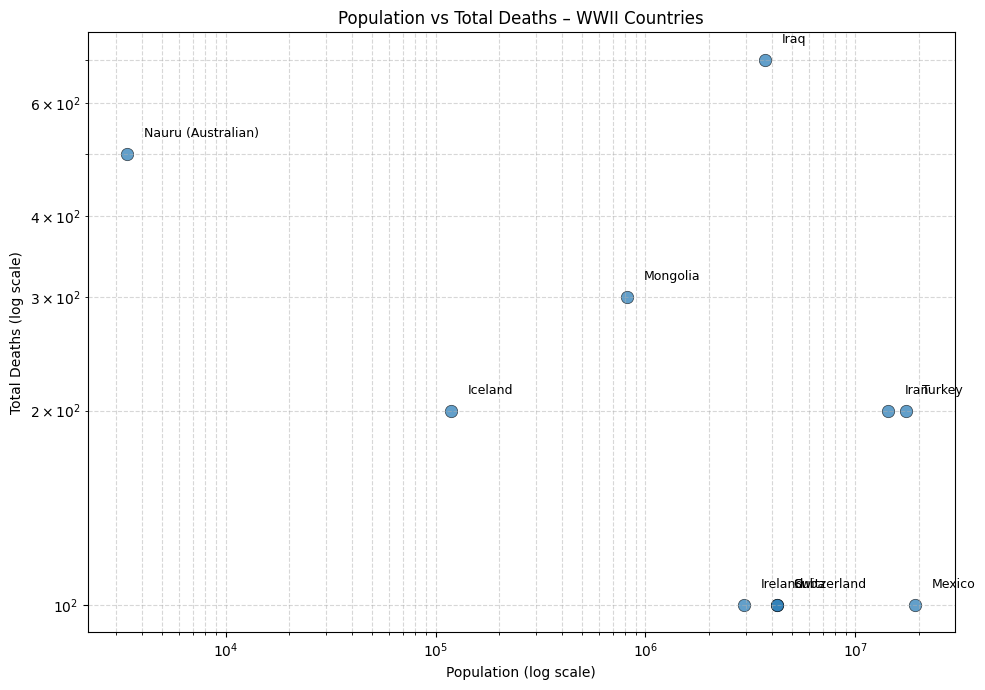

In [ ]:

# مطمئن شو که عددی هستند (دوباره)
df['Pop'] = pd.to_numeric(df['Pop'], errors='coerce')
df['TotalDeaths'] = pd.to_numeric(df['TotalDeaths'], errors='coerce')

# حذف ردیف‌هایی که حداقل یکی NaN است (اختیاری اما توصیه می‌شود)
df_plot = df.dropna(subset=['Pop', 'TotalDeaths'])

plt.figure(figsize=(10, 7))

plt.scatter(df_plot['Pop'], df_plot['TotalDeaths'],
            alpha=0.7, s=80, edgecolor='black', linewidth=0.5)

# اگر داده‌ها خیلی پراکنده‌اند → log scale خیلی کمک می‌کند
plt.xscale('log')
plt.yscale('log')

plt.xlabel("Population (log scale)")
plt.ylabel("Total Deaths (log scale)")
plt.title("Population vs Total Deaths – WWII Countries")

# grid بهتر برای log
plt.grid(True, which="both", ls="--", alpha=0.5)

# اختیاری: نام چند کشور مهم را اضافه کن
for i, row in df_plot.nlargest(12, 'TotalDeaths').iterrows():
    plt.annotate(row.get('Country', ''), 
                 (row['Pop'], row['TotalDeaths']),
                 xytext=(8, 8), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

### ۳. همبستگی بین داده ها را مشخص کنید. 


In [ ]:

import re

def clean_numeric(val):
    if pd.isna(val) or val == '' or str(val).strip() == 'NA':
        return np.nan

    s = str(val).strip()

    # Handle special non-numeric entries
    if any(keyword in s for keyword in ['Included', 'See table', '(included', 'BF1', 'BF2']):
        return np.nan

    # Remove everything inside square brackets and the brackets themselves
    s = re.sub(r'\[.*?\]', '', s)

    # Handle ranges like "5,000 to 10,000" or "5000to10000"
    range_match = re.search(r'([\d,]+)\s*to\s*([\d,]+)', s, re.IGNORECASE)
    if range_match:
        try:
            low = float(range_match.group(1).replace(',', ''))
            high = float(range_match.group(2).replace(',', ''))
            return (low + high) / 2
        except ValueError:
            return np.nan

    # Remove commas and extra spaces
    s = re.sub(r'[,\s]', '', s)

    # Extract first valid number if any (in case of trailing garbage)
    num_match = re.match(r'^-?\d+(?:\.\d+)?', s)
    if num_match:
        try:
            return float(num_match.group(0))
        except ValueError:
            return np.nan
    else:
        return np.nan
df.columns = df.columns.str.strip()
# Identify columns that should be numeric (excluding Country)
numeric_cols = [col for col in df.columns if col != 'Country']

# Apply cleaning
for col in numeric_cols:
    df[col] = df[col].apply(clean_numeric)



In [118]:

# Compute correlation matrix
corr = df[numeric_cols].corr()
corr.round(4)

,Pop,Militarydeaths from all causes,CivViolence,CivFamineDisease,TotalDeaths,DeathRate,DeathPct1939,MilWounded
Pop,1.0000,0.4510,0.8043,0.7076,-0.3119,-0.0436,-0.0529,0.2722
Militarydeaths from all causes,0.4510,1.0000,0.7371,0.8487,-0.4253,-0.0327,0.0726,0.9659
CivViolence,0.8043,0.7371,1.0000,0.9492,0.6333,0.0077,0.3123,0.6414
CivFamineDisease,0.7076,0.8487,0.9492,1.0000,NaN,0.5021,-0.0502,0.7410
TotalDeaths,-0.3119,-0.4253,0.6333,NaN,1.0000,-0.4879,0.4366,NaN
DeathRate,-0.0436,-0.0327,0.0077,0.5021,-0.4879,1.0000,0.1341,-0.0485
DeathPct1939,-0.0529,0.0726,0.3123,-0.0502,0.4366,0.1341,1.0000,0.3192
MilWounded,0.2722,0.9659,0.6414,0.7410,NaN,-0.0485,0.3192,1.0000


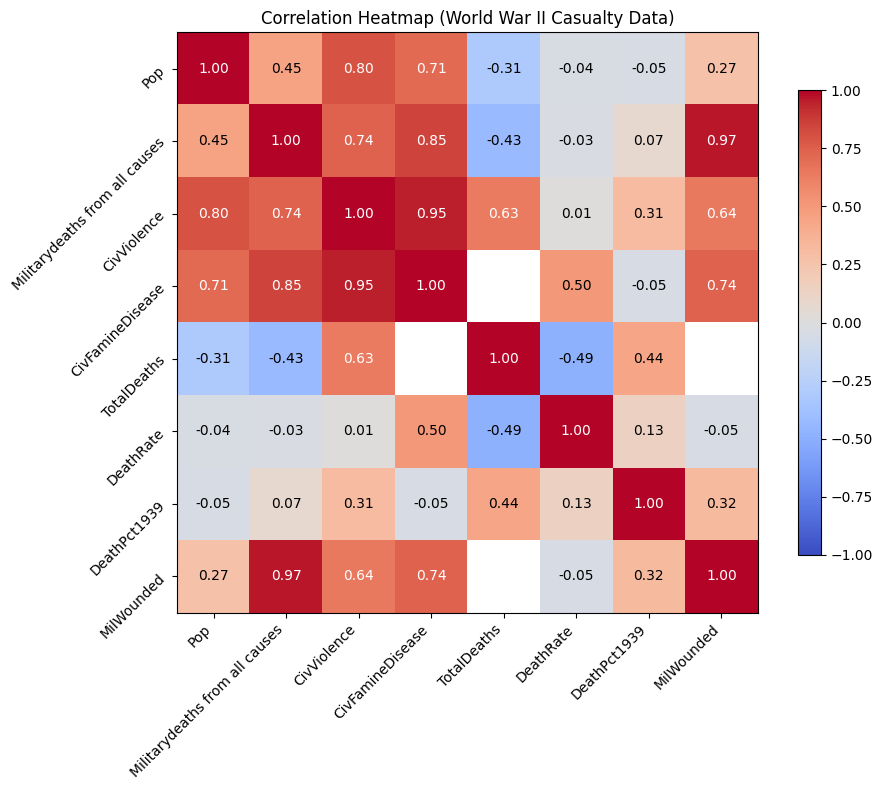

In [119]:

# Plot heatmap with matplotlib
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns, rotation=45, ha='right')

# Add colorbar
fig.colorbar(cax, shrink=0.8)

# Add correlation values as text
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        text = ax.text(j, i, f"{corr.iloc[i, j]:.2f}" if not pd.isna(corr.iloc[i, j]) else "",
                       ha="center", va="center", color="black" if abs(corr.iloc[i, j]) < 0.6 else "white")

plt.title("Correlation Heatmap (World War II Casualty Data)")
plt.tight_layout()
plt.show()

### ۴. یک ستون از داده ها را حذف کنید و مجدد داده ها را چاپ کنید. 


In [120]:
df.drop(columns=["Pop"], inplace=True)

In [121]:
df.head(3)


,Country,Militarydeaths from all causes,CivViolence,CivFamineDisease,TotalDeaths,DeathRate,DeathPct1939,MilWounded
0,Albania,30000.0,NaN,NaN,NaN,0.027959,2.80,NaN
1,Australia,39700.0,700.0,NaN,NaN,0.005798,0.58,39803.0
2,Austria,NaN,NaN,NaN,0.0,0.000000,NaN,NaN


### ۵. دو ستون از داده ها را در نظر بگیرید و نمودار scatter چاپ کنید. 


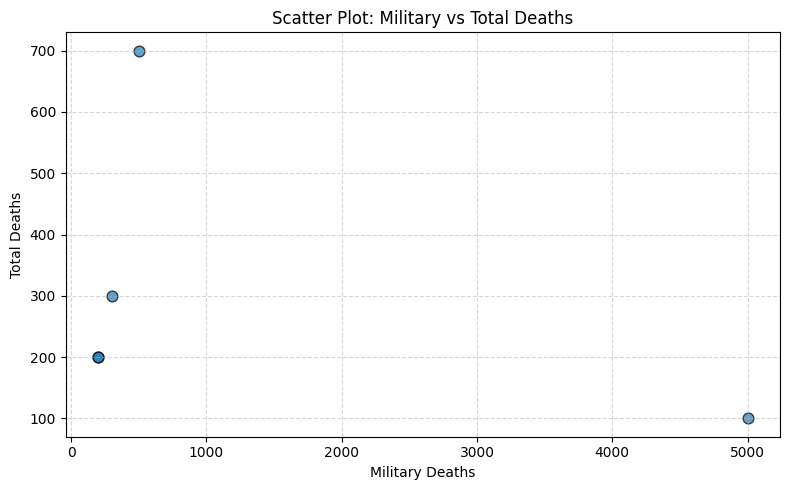

In [122]:

col_mil = 'Militarydeaths from all causes'
col_death = 'TotalDeaths'

# Check if columns exist
if col_mil not in df.columns or col_death not in df.columns:
    raise KeyError(f"Columns not found. Available: {list(df.columns)}")

x = df[col_mil]
y = df[col_death]

# Drop NaN rows
mask = ~(x.isna() | y.isna())
x_clean = x[mask]
y_clean = y[mask]

# Plot scatter
plt.figure(figsize=(8, 5))
plt.scatter(x_clean, y_clean, alpha=0.7, edgecolors='k', s=60)
plt.xlabel('Military Deaths')
plt.ylabel('Total Deaths')
plt.title('Scatter Plot: Military vs Total Deaths')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### ۶. با استفاده از روش های یادگیری ماشین و تقسیم داده ها به دو قسمت آموزشی و آزمایشی کار یادگیری را انجام دهید. 


In [123]:
y = df["TotalDeaths"]
X = df.drop(columns=["Country", "TotalDeaths", "DeathPct1939"])


In [124]:
# split date to train and test 80 / 20

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Shape of training set:", X_train.shape)
print("Missing values in X_train:", X_train.isnull().sum().sum())

Shape of training set: (48, 5)
Missing values in X_train: 93


#### ۷. یک روش مناسب برای جایگزینی داده های از دست رفته اعمال کنید. اگر داده از دست رفته ندارید به تصادف تعدادی از داده ها را جایگزین کنید. 


In [125]:


from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score



# Impute missing values using TRAIN medians only
median_vals = X_train.median()
X_train = X_train.fillna(median_vals)
X_test = X_test.fillna(median_vals)
y_train = y_train.fillna(y_train.median())
y_test = y_test.fillna(y_train.median())  # Use train median for test too


In [126]:

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Train SVM
svm_model = SVR(kernel='rbf', C=100, gamma=0.1)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

# Evaluate models
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
svm_mae = mean_absolute_error(y_test, svm_pred)
svm_r2 = r2_score(y_test, svm_pred)

# Print results in a readable format
print("=== Model Performance ===")
print(f"Random Forest - R² Score: {rf_r2:.4f}, MAE: {rf_mae:,.0f}")
print(f"SVM (RBF)     - R² Score: {svm_r2:.4f}, MAE: {svm_mae:,.0f}")

# Interpretation
if rf_r2 > svm_r2:
    print("\n→ Random Forest performs better on this dataset.")
else:
    print("\n→ SVM performs better on this dataset.")




=== Model Performance ===
Random Forest - R² Score: -0.0787, MAE: 33
SVM (RBF)     - R² Score: -0.0616, MAE: 33

→ SVM performs better on this dataset.


In [127]:

feature_importance = pd.DataFrame({
    'feature': X_train.columns,  
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                          feature  importance
3                       DeathRate    0.447449
0  Militarydeaths from all causes    0.391406
1                     CivViolence    0.160521
4                      MilWounded    0.000625
2                CivFamineDisease    0.000000


In [128]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load and clean the dataset
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

def clean_numeric(val):
    """Clean numeric values by removing footnotes, handling ranges, and converting to float."""
    if pd.isna(val) or val == '' or 'Included' in str(val) or 'See table' in str(val) or 'NA' in str(val):
        return np.nan
    # Remove anything after '[' (e.g., [17])
    val = str(val).split('[')[0]
    # Handle ranges like "5,000 to 10,000"
    if 'to' in val:
        parts = val.split('to')
        try:
            low = float(parts[0].replace(',', '').strip())
            high = float(parts[1].replace(',', '').strip())
            return (low + high) / 2
        except:
            return np.nan
    # Remove commas and convert to float
    val = val.replace(',', '').strip()
    try:
        return float(val)
    except:
        return np.nan

# Apply cleaning to all columns except 'Country'
numeric_cols = [col for col in df.columns if col != 'Country']
for col in numeric_cols:
    df[col] = df[col].apply(clean_numeric)

# 2. Drop non-numeric or unusable columns
df = df.drop(columns=['Country', 'Average Deaths as % of 1939 population'], errors='ignore')

# 3. Define features (X) and target (y)
y = df['Totaldeaths']
X = df.drop(columns=['Totaldeaths'])

# 4. Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Impute missing values using median from training set only (to prevent data leakage)
median_X = X_train.median()
median_y = y_train.median()

X_train = X_train.fillna(median_X)
X_test = X_test.fillna(median_X)
y_train = y_train.fillna(median_y)
y_test = y_test.fillna(median_y)

# ==================================================
# 6. Train Random Forest with hyperparameter tuning
# ==================================================
rf = RandomForestRegressor(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# ==================================================
# 7. Train SVM with scaling and hyperparameter tuning
# ==================================================
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # SVM is sensitive to feature scales
    ('svm', SVR())
])

svm_params = {
    'svm__C': [1, 10, 100, 1000],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'svm__epsilon': [0.01, 0.1, 0.2]
}

svm_grid = GridSearchCV(svm_pipeline, svm_params, cv=5, scoring='r2', n_jobs=-1)
svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_
svm_pred = best_svm.predict(X_test)
svm_mae = mean_absolute_error(y_test, svm_pred)
svm_r2 = r2_score(y_test, svm_pred)

# ==================================================
# 8. Display results
# ==================================================
print("=== Optimized Model Performance ===")
print(f"Random Forest - R²: {rf_r2:.4f}, MAE: {rf_mae:,.0f}")
print(f"SVM (RBF)     - R²: {svm_r2:.4f}, MAE: {svm_mae:,.0f}")
print("\nBest Random Forest parameters:", rf_grid.best_params_)
print("Best SVM parameters:", {k.replace('svm__', ''): v for k, v in svm_grid.best_params_.items()})

=== Optimized Model Performance ===
Random Forest - R²: -2.4792, MAE: 646,133
SVM (RBF)     - R²: -0.0905, MAE: 350,901

Best Random Forest parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best SVM parameters: {'C': 1000, 'epsilon': 0.01, 'gamma': 1}
